# Assignment 5 — Fashion-MNIST với CNN

**Môn:** Phân tích và Phát triển Hệ thống Thông minh

Notebook này đi theo thứ tự:

1. Giới thiệu bài toán và dữ liệu  
2. Load + khảo sát dữ liệu  
3. Tiền xử lý  
4. CNN cơ bản → train → đánh giá  
5. LeNet-like → train → đánh giá  
6. VGG-like → train → đánh giá  
7. ResNet-like → train → đánh giá  
8. So sánh 4 mô hình  
9. Kết luận

Ba mô hình cải tiến được chọn dựa trên các kiến trúc CNN thường được trình bày trong phần “mô hình cải tiến từ CNN”: **LeNet, VGG, ResNet**.

## 1. Cấu trúc CNN dùng trong bài

Luồng cơ bản:

`Input → Conv2D → ReLU → Pooling → Conv2D → ReLU → Pooling → Flatten/GAP → Dense → Softmax`

Với ảnh Fashion-MNIST:
- kích thước ảnh: `28 × 28 × 1`
- số lớp: `10`
- output: `Dense(10, activation="softmax")`

In [1]:
from pathlib import Path
import time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
RESULT_DIR = PROJECT_DIR / "outputs" / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

PROJECT_DIR: D:\Assignment5\Assignment5_CNN_Project
TensorFlow: 2.21.0
GPU: []


## 2. Load và khảo sát Fashion-MNIST

In [2]:
FASHION_DIR = DATA_DIR / "fashion_mnist"
TRAIN_CSV = FASHION_DIR / "fashion-mnist_train.csv"
TEST_CSV = FASHION_DIR / "fashion-mnist_test.csv"

assert TRAIN_CSV.exists(), f"Không tìm thấy {TRAIN_CSV}"
assert TEST_CSV.exists(), f"Không tìm thấy {TEST_CSV}"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
display(train_df.head())
print("Missing train:", int(train_df.isna().sum().sum()))
print("Missing test :", int(test_df.isna().sum().sum()))

Train shape: (60000, 785)
Test shape : (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Missing train: 0
Missing test : 0


In [3]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(train_df["label"].value_counts().sort_index())

label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


## 3. Tiền xử lý dữ liệu

In [4]:
from sklearn.model_selection import train_test_split

X_train_full = train_df.drop(columns=["label"]).to_numpy(dtype=np.float32) / 255.0
y_train_full = train_df["label"].to_numpy(dtype=np.int64)

X_test = test_df.drop(columns=["label"]).to_numpy(dtype=np.float32) / 255.0
y_test = test_df["label"].to_numpy(dtype=np.int64)

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=SEED, stratify=y_train_full
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (48000, 28, 28, 1)
Val  : (12000, 28, 28, 1)
Test : (10000, 28, 28, 1)


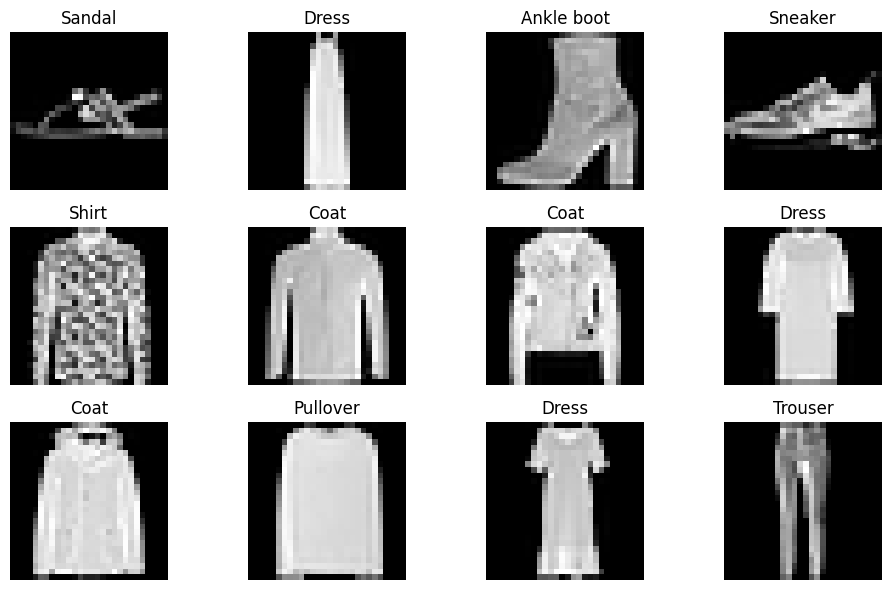

In [5]:
plt.figure(figsize=(10, 6))
idxs = np.random.default_rng(SEED).choice(len(X_train), 12, replace=False)

for i, idx in enumerate(idxs):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[idx].squeeze(), cmap="gray")
    plt.title(CLASS_NAMES[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
def plot_history(history, dataset_name, model_name):
    h = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(h["accuracy"], label="Train")
    plt.plot(h["val_accuracy"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{dataset_name} - {model_name} - Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_accuracy.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(h["loss"], label="Train")
    plt.plot(h["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{dataset_name} - {model_name} - Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_loss.png", dpi=150)
    plt.show()


def evaluate_multiclass(model, X_or_ds, y_true, dataset_name, model_name, class_names):
    probs = model.predict(X_or_ds, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    row = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "params": int(model.count_params()),
    }

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{dataset_name} - {model_name}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_confusion_matrix.png", dpi=150)
    plt.show()

    return row

## 4. CNN cơ bản

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8189 - loss: 0.5125 - val_accuracy: 0.8598 - val_loss: 0.3745
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8875 - loss: 0.3175 - val_accuracy: 0.8737 - val_loss: 0.3420
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9032 - loss: 0.2731 - val_accuracy: 0.8796 - val_loss: 0.3282
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9131 - loss: 0.2428 - val_accuracy: 0.8894 - val_loss: 0.3043
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9220 - loss: 0.2183 - val_accuracy: 0.8956 - val_loss: 0.2893


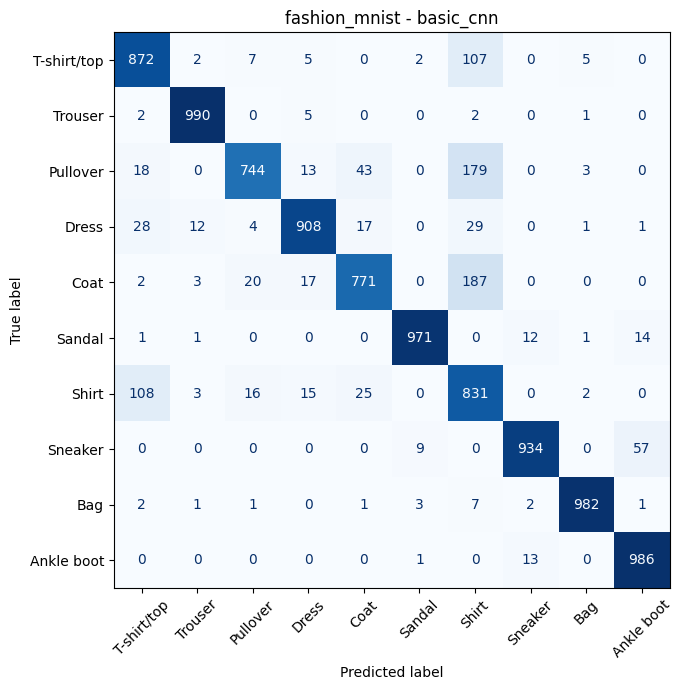

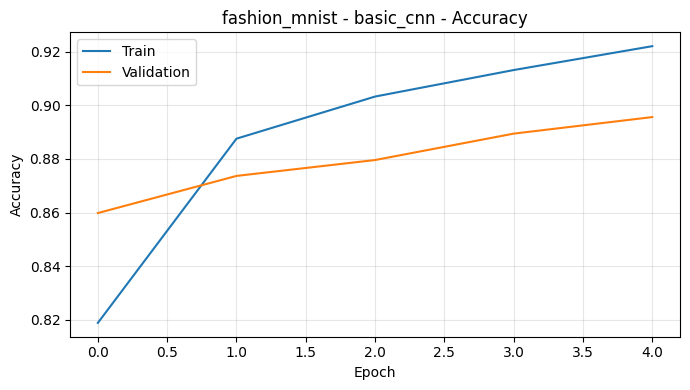

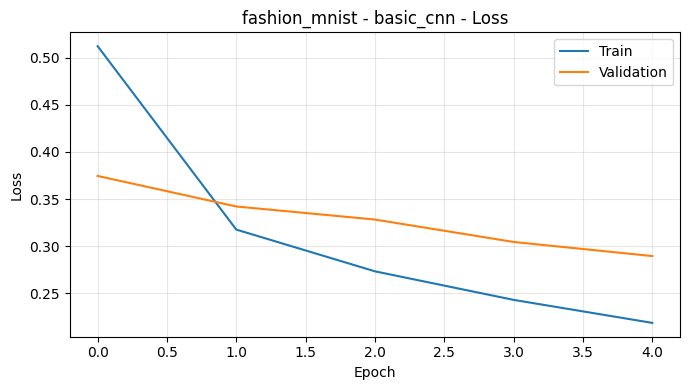

In [7]:
def build_basic_fashion():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

results = []
EPOCHS = 5
BATCH_SIZE = 128

model = build_basic_fashion()
model.summary()

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
row = evaluate_multiclass(model, X_test, y_test, "fashion_mnist", "basic_cnn", CLASS_NAMES)
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "fashion_mnist", "basic_cnn")
model.save(MODEL_DIR / "fashion_mnist_basic_cnn.keras")

## 5. Mô hình cải tiến 1 — LeNet-like

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ zero_padding2d (ZeroPadding2D)       │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7625 - loss: 0.6531 - val_accuracy: 0.8125 - val_loss: 0.5015
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8401 - loss: 0.4418 - val_accuracy: 0.8454 - val_loss: 0.4166
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8595 - loss: 0.3874 - val_accuracy: 0.8597 - val_loss: 0.3794
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8708 - loss: 0.3560 - val_accuracy: 0.8683 - val_loss: 0.3588
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8788 - loss: 0.3339 - val_accuracy: 0.8722 - val_loss: 0.3459


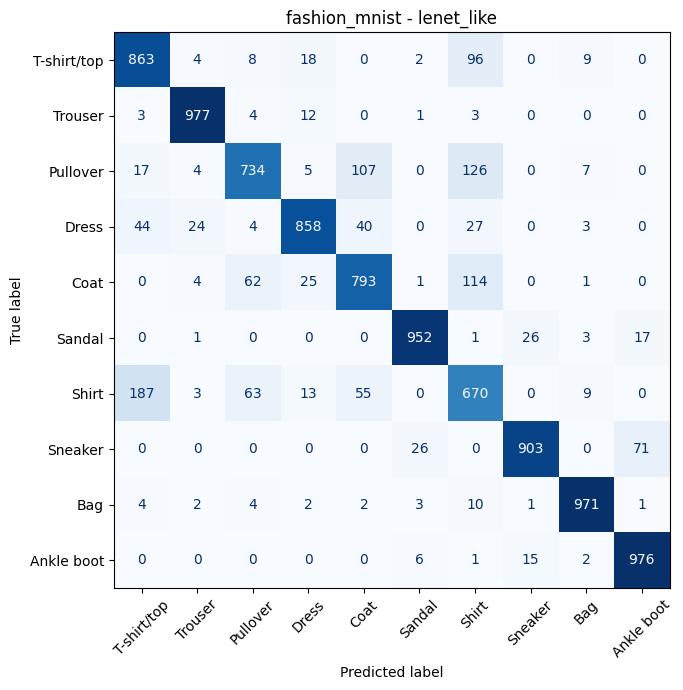

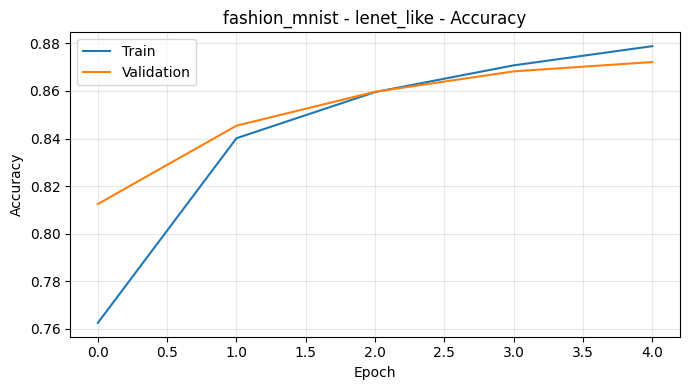

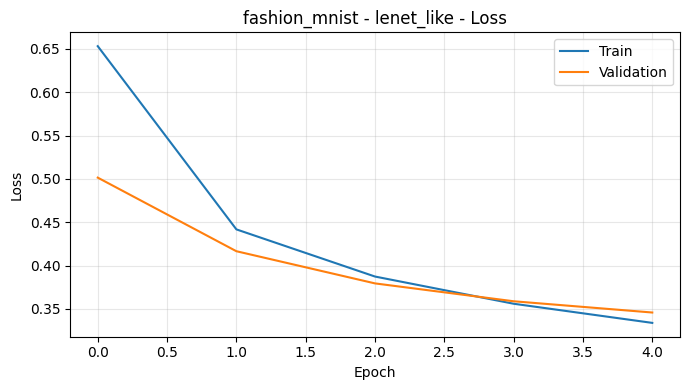

In [8]:
def build_lenet_fashion():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.ZeroPadding2D(padding=2),          # 28x28 -> 32x32
        layers.Conv2D(6, 5, activation="tanh"),  # gần tinh thần LeNet-5
        layers.AveragePooling2D(2),
        layers.Conv2D(16, 5, activation="tanh"),
        layers.AveragePooling2D(2),
        layers.Flatten(),
        layers.Dense(120, activation="tanh"),
        layers.Dense(84, activation="tanh"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_lenet_fashion()
model.summary()

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
row = evaluate_multiclass(model, X_test, y_test, "fashion_mnist", "lenet_like", CLASS_NAMES)
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "fashion_mnist", "lenet_like")
model.save(MODEL_DIR / "fashion_mnist_lenet_like.keras")

## 6. Mô hình cải tiến 2 — VGG-like

Model: "vgg_like"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 156,650 (611.91 KB)

 Trainable params: 156,650 (611.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - accuracy: 0.6255 - loss: 0.9832 - val_accuracy: 0.7660 - val_loss: 0.6065
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.7770 - loss: 0.6038 - val_accuracy: 0.8063 - val_loss: 0.5190
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.8150 - loss: 0.5082 - val_accuracy: 0.8282 - val_loss: 0.4470
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 83ms/step - accuracy: 0.8396 - loss: 0.4488 - val_accuracy: 0.8458 - val_loss: 0.3971
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - accuracy: 0.8571 - loss: 0.3996 - val_accuracy: 0.8644 - val_loss: 0.3503


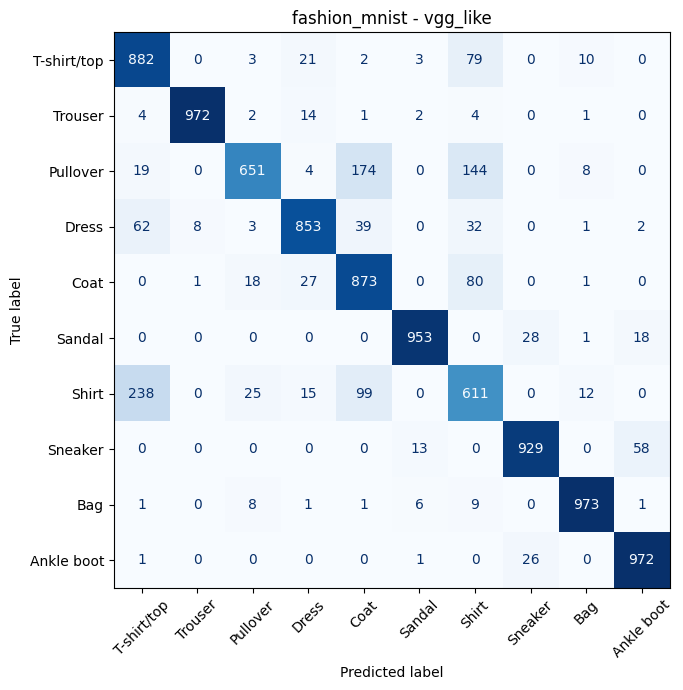

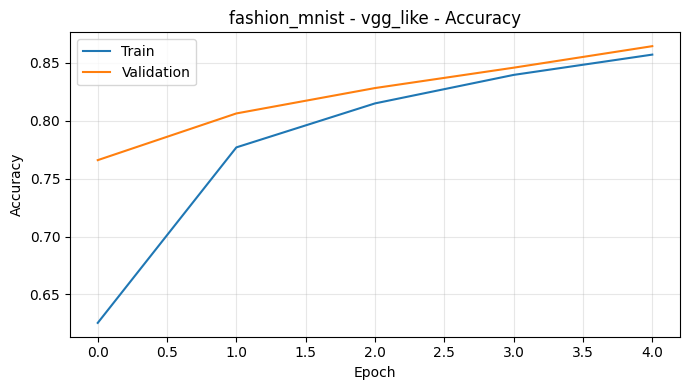

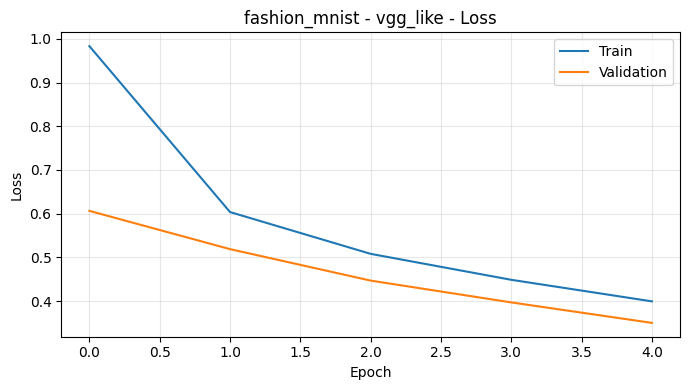

In [9]:
def build_vgg_fashion():
    inputs = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="vgg_like")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_vgg_fashion()
model.summary()

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
row = evaluate_multiclass(model, X_test, y_test, "fashion_mnist", "vgg_like", CLASS_NAMES)
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "fashion_mnist", "vgg_like")
model.save(MODEL_DIR / "fashion_mnist_vgg_like.keras")

## 7. Mô hình cải tiến 3 — ResNet-like

Model: "resnet_like"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 28, 28, 32)        │             288 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 28, 28, 32)        │             128 │ conv2d_9[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu (ReLU)                  │ (None, 28, 28, 32)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 28, 28, 32)        │           9,216 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 28, 28, 32)        │             128 │ conv2d_10[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_1 (ReLU)                │ (None, 28, 28, 32)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 28, 28, 32)        │           9,216 │ re_lu_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 28, 28, 32)        │             128 │ conv2d_11[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 28, 28, 32)        │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 28, 28, 32)        │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 14, 14, 64)        │          18,432 │ re_lu_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 14, 14, 64)        │             256 │ conv2d_12[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 14, 14, 64)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_13 (Conv2D)            │ (None, 14, 14, 64)        │          36,86

 Total params: 152,106 (594.16 KB)

 Trainable params: 151,274 (590.91 KB)

 Non-trainable params: 832 (3.25 KB)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 118s 271ms/step - accuracy: 0.7924 - loss: 0.6097 - val_accuracy: 0.1436 - val_loss: 5.4566
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 115s 307ms/step - accuracy: 0.8716 - loss: 0.3604 - val_accuracy: 0.7907 - val_loss: 0.5972
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 112s 299ms/step - accuracy: 0.8911 - loss: 0.3044 - val_accuracy: 0.8377 - val_loss: 0.4332
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 115s 307ms/step - accuracy: 0.9030 - loss: 0.2710 - val_accuracy: 0.8335 - val_loss: 0.4549
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 121s 322ms/step - accuracy: 0.9103 - loss: 0.2493 - val_accuracy: 0.8297 - val_loss: 0.5604


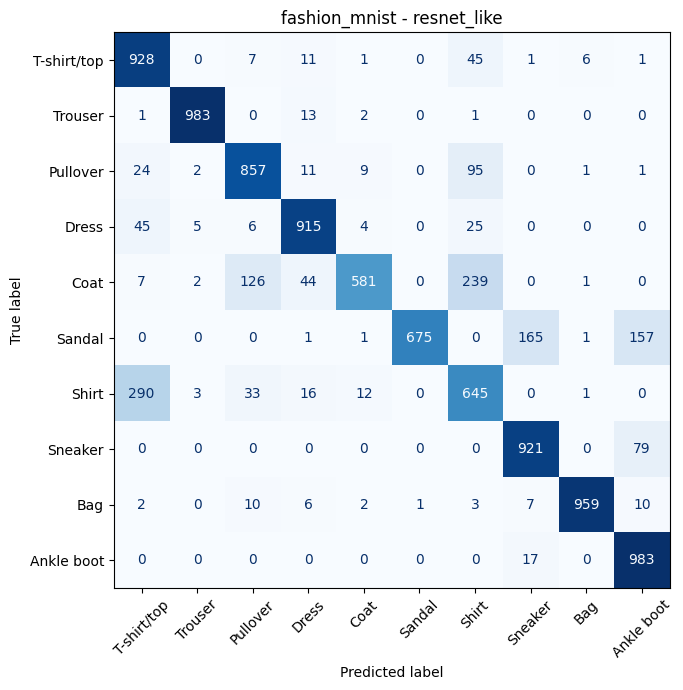

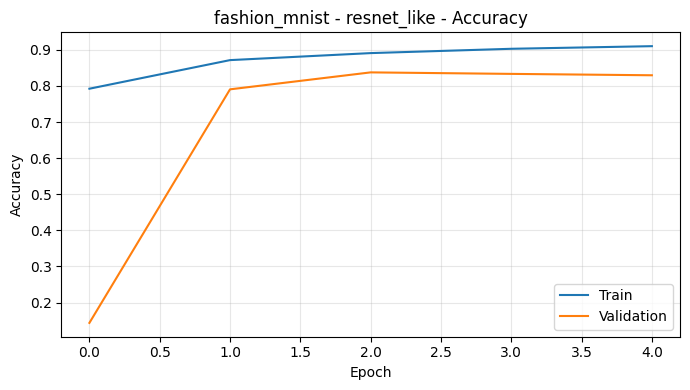

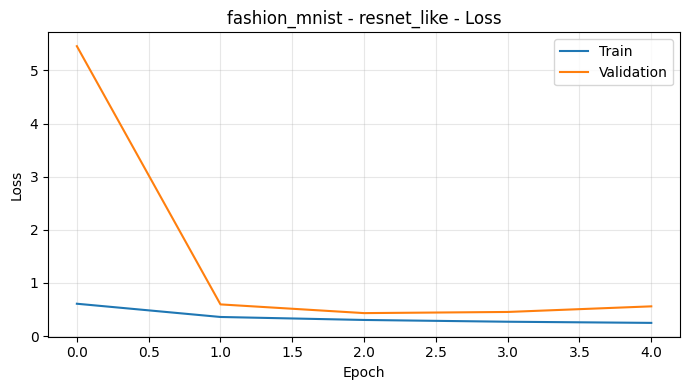

In [10]:
def residual_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)

def build_resnet_fashion():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="resnet_like")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_resnet_fashion()
model.summary()

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
row = evaluate_multiclass(model, X_test, y_test, "fashion_mnist", "resnet_like", CLASS_NAMES)
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "fashion_mnist", "resnet_like")
model.save(MODEL_DIR / "fashion_mnist_resnet_like.keras")

## 8. So sánh kết quả

,dataset,model,accuracy,precision_macro,recall_macro,f1_macro,params,loss,train_seconds
0,fashion_mnist,basic_cnn,0.8989,0.909825,0.8989,0.901006,421642,0.279220,48.646287
1,fashion_mnist,lenet_like,0.8697,0.871885,0.8697,0.869891,61706,0.348521,33.012060
2,fashion_mnist,vgg_like,0.8669,0.873269,0.8669,0.866307,156650,0.345660,157.175351
3,fashion_mnist,resnet_like,0.8447,0.860558,0.8447,0.842394,152106,0.426836,581.294639


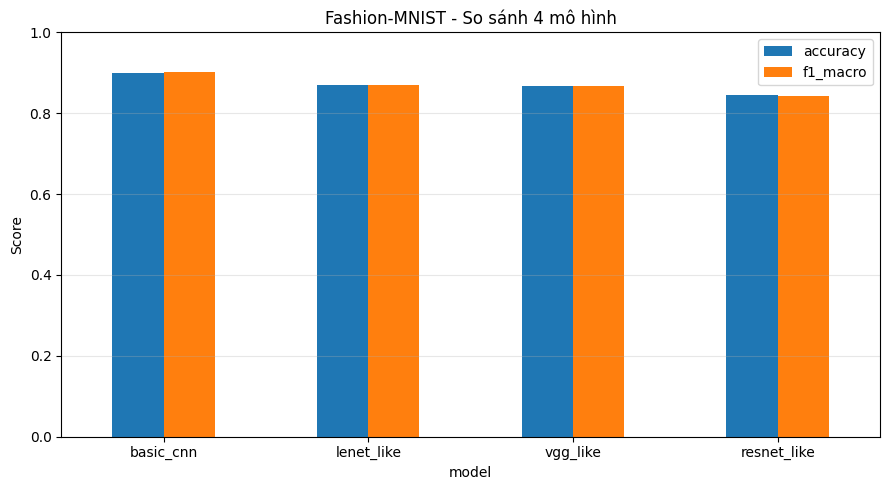

In [11]:
results_df = pd.DataFrame(results)
display(results_df.sort_values("accuracy", ascending=False))

results_df.to_csv(RESULT_DIR / "fashion_mnist_results.csv", index=False)

ax = results_df.set_index("model")[["accuracy", "f1_macro"]].plot(
    kind="bar", figsize=(9, 5)
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Fashion-MNIST - So sánh 4 mô hình")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fashion_mnist_model_comparison.png", dpi=150)
plt.show()

## 9. Kết luận

Sau khi chạy, hãy dựa trên **Accuracy, Macro-F1, Loss, số tham số và thời gian train** để nhận xét.  
Không kết luận trước mô hình nào tốt hơn nếu chưa có kết quả thực nghiệm.